In [10]:
# Setup
import os, sys, torch
from argparse import Namespace

repo_root = "/scratch/jq2uw/MME/instruct_vlm_edit"
os.chdir(repo_root)
sys.path.append(repo_root) if repo_root not in sys.path else None

from revlm.config_utils import configure_args
from revlm import VQAModel, VQADataset
from revlm.editors.auto_q import BiasLayer


In [11]:
# Load model & dataset
model_name = "qwen3_4b"  # Options: "blip", "llava", "qwen3", "qwen3_4b"

args = Namespace(config="revlm/config/config.yaml", editor="ike_chain", model_name=model_name,
                 dataset_name="aokvqa", task="mc", batch_size=1, split="all",
                 rationale=False, cot=False, subsample=100, overwrite=False)
args.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
config = configure_args(args, config_path=args.config)

model = VQAModel(config)
dataset = VQADataset(config)
print(f"Model: {config.model.name}, Dataset: {len(dataset)} samples")


Task evaluation metrics will be saved to results/te/ike_chain/Qwen3-VL-4B-Instruct/aokvqa
Edit evaluation metrics will be saved to results/ee/ike_chain/Qwen3-VL-4B-Instruct/aokvqa
Predictions will be saved to results/pred/Qwen3-VL-4B-Instruct/aokvqa
Post-edit predictions will be saved to results/pred_postedit/ike_chain/Qwen3-VL-4B-Instruct/aokvqa
Unified filename to save: mc_all_sub100.json
Model: Qwen/Qwen3-VL-4B-Instruct, Dataset: 18195 samples


In [12]:
# Initialize BiasLayer and get candidate layers
bias = BiasLayer(config, model, pool_method="last")
layers = bias.get_candidate_layers()


[BiasLayer] 92 layers (vision: 48, merger: 8, language: 36)


In [13]:
# Compute bias at each layer (OPTIMIZED: batched forward passes)
scores = bias.compute(dataset, layers, n_samples=10)


[Augmenter] Loading Qwen/Qwen2.5-1.5B-Instruct...
[BiasLayer] 10 samples, 92 layers, 90 forwards (batched)


computing:  37%|██████████████████                               | 34/92 [00:00<00:00, 165.78it/s]

  model.visual.blocks.0.mlp.linear_fc1.weight: vis=+19.589, txt=-18.507
  model.visual.blocks.0.mlp.linear_fc2.weight: vis=+15.273, txt=-13.965
  model.visual.blocks.1.mlp.linear_fc1.weight: vis=+22.330, txt=-21.259
  model.visual.blocks.1.mlp.linear_fc2.weight: vis=+8.258, txt=-8.217
  model.visual.blocks.2.mlp.linear_fc1.weight: vis=+19.766, txt=-20.386
  model.visual.blocks.2.mlp.linear_fc2.weight: vis=+7.855, txt=-8.271
  model.visual.blocks.3.mlp.linear_fc1.weight: vis=+20.551, txt=-20.981
  model.visual.blocks.3.mlp.linear_fc2.weight: vis=+6.466, txt=-6.873
  model.visual.blocks.4.mlp.linear_fc1.weight: vis=+23.113, txt=-23.385
  model.visual.blocks.4.mlp.linear_fc2.weight: vis=+7.721, txt=-8.320
  model.visual.blocks.5.mlp.linear_fc1.weight: vis=+24.811, txt=-25.043
  model.visual.blocks.5.mlp.linear_fc2.weight: vis=+8.892, txt=-9.145
  model.visual.blocks.6.mlp.linear_fc1.weight: vis=+24.444, txt=-24.775
  model.visual.blocks.6.mlp.linear_fc2.weight: vis=+9.396, txt=-9.778
  mo

computing:  55%|███████████████████████████▏                     | 51/92 [00:00<00:00, 155.00it/s]

  model.visual.blocks.17.mlp.linear_fc1.weight: vis=+135.766, txt=-141.457
  model.visual.blocks.17.mlp.linear_fc2.weight: vis=+15.084, txt=-18.271
  model.visual.blocks.18.mlp.linear_fc1.weight: vis=+211.186, txt=-219.988
  model.visual.blocks.18.mlp.linear_fc2.weight: vis=+9.805, txt=-12.375
  model.visual.blocks.19.mlp.linear_fc1.weight: vis=+251.700, txt=-267.357
  model.visual.blocks.19.mlp.linear_fc2.weight: vis=+14.447, txt=-12.895
  model.visual.blocks.20.mlp.linear_fc1.weight: vis=+280.786, txt=-299.768
  model.visual.blocks.20.mlp.linear_fc2.weight: vis=+16.508, txt=-20.209
  model.visual.blocks.21.mlp.linear_fc1.weight: vis=+305.271, txt=-342.744
  model.visual.blocks.21.mlp.linear_fc2.weight: vis=+32.960, txt=-34.338
  model.visual.blocks.22.mlp.linear_fc1.weight: vis=+282.710, txt=-327.123
  model.visual.blocks.22.mlp.linear_fc2.weight: vis=+46.965, txt=-53.880
  model.visual.blocks.23.mlp.linear_fc1.weight: vis=+203.086, txt=-238.600
  model.visual.blocks.23.mlp.linear_fc

computing: 100%|█████████████████████████████████████████████████| 92/92 [00:00<00:00, 161.15it/s]


  model.language_model.layers.9.mlp.gate_proj.weight: vis=-3.352, txt=-2.210
  odel.language_model.layers.10.mlp.gate_proj.weight: vis=-2.882, txt=-1.989
  odel.language_model.layers.11.mlp.gate_proj.weight: vis=-3.396, txt=-1.181
  odel.language_model.layers.12.mlp.gate_proj.weight: vis=-4.699, txt=-0.390
  odel.language_model.layers.13.mlp.gate_proj.weight: vis=-4.651, txt=-0.377
  odel.language_model.layers.14.mlp.gate_proj.weight: vis=-5.344, txt=-0.434
  odel.language_model.layers.15.mlp.gate_proj.weight: vis=-5.329, txt=-0.222
  odel.language_model.layers.16.mlp.gate_proj.weight: vis=-5.811, txt=-0.028
  odel.language_model.layers.17.mlp.gate_proj.weight: vis=-6.464, txt=+0.329
  odel.language_model.layers.18.mlp.gate_proj.weight: vis=-7.493, txt=+0.367
  odel.language_model.layers.19.mlp.gate_proj.weight: vis=-9.055, txt=+0.858
  odel.language_model.layers.20.mlp.gate_proj.weight: vis=-10.477, txt=+1.194
  odel.language_model.layers.21.mlp.gate_proj.weight: vis=-12.393, txt=+1.3

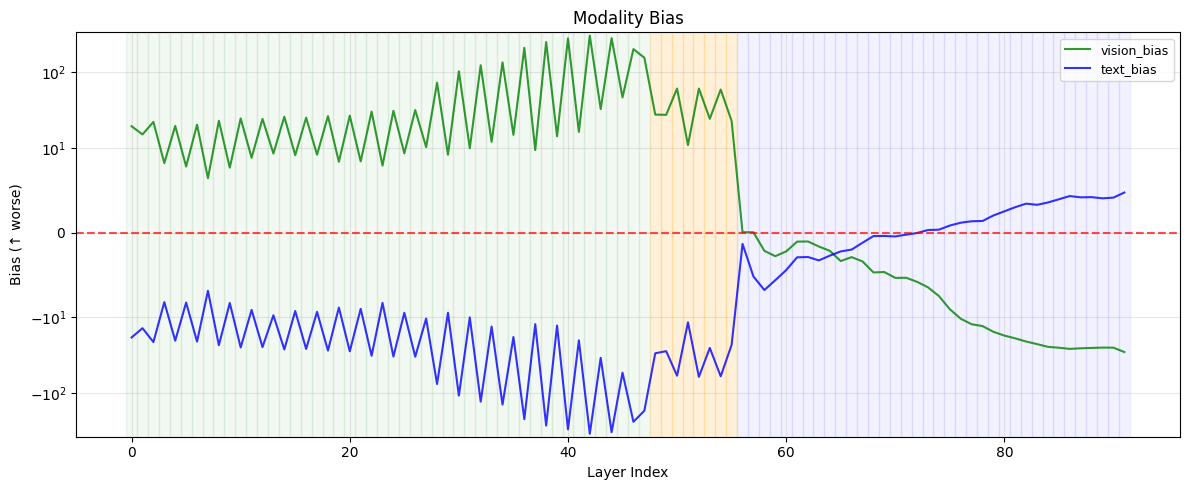

In [14]:
# Plot bias scores
bias.plot(scores)


In [15]:
# Cleanup
bias.cleanup()
del model
torch.cuda.empty_cache()


# Load Saved Results (After Running Jobs)

After running `jobs/bias_layer/run.sh`, use the cells below to load aggregated results with error bars.


In [16]:
# Setup for loading saved results
import os, sys, torch
from argparse import Namespace

repo_root = "/scratch/jq2uw/MME/instruct_vlm_edit"
os.chdir(repo_root)
sys.path.append(repo_root) if repo_root not in sys.path else None

from revlm.config_utils import configure_args
from revlm.editors.auto_q import BiasLayer


In [19]:
# Load aggregated results from saved runs (with error bars)
model_name = "qwen3_4b"  # Options: "blip", "llava", "qwen3", "qwen3_4b"
pool_method = "mean"     # Options: "mean", "last"

args = Namespace(config="revlm/config/config.yaml", editor="ike_chain", model_name=model_name,
                 dataset_name="aokvqa", task="mc", batch_size=1, split="all",
                 rationale=False, cot=False)
args.device = torch.device("cpu")
config = configure_args(args, config_path=args.config)

# Create BiasLayer just for loading (no model needed)
bias_loader = BiasLayer.__new__(BiasLayer)
bias_loader.config = config
bias_loader.device = args.device
bias_loader.pool_method = pool_method

# Load aggregated results
agg_scores = bias_loader.load_results_k(out_dir="results/bias_layer")
if agg_scores:
    print(f"Loaded {len(agg_scores)} layers")


Task evaluation metrics will be saved to results/te/ike_chain/Qwen3-VL-4B-Instruct/aokvqa
Edit evaluation metrics will be saved to results/ee/ike_chain/Qwen3-VL-4B-Instruct/aokvqa
Predictions will be saved to results/pred/Qwen3-VL-4B-Instruct/aokvqa
Post-edit predictions will be saved to results/pred_postedit/ike_chain/Qwen3-VL-4B-Instruct/aokvqa
Unified filename to save: mc_all.json
[BiasLayer] Loading 10 runs...
[BiasLayer] Aggregated 10 runs, 92 layers
Loaded 92 layers


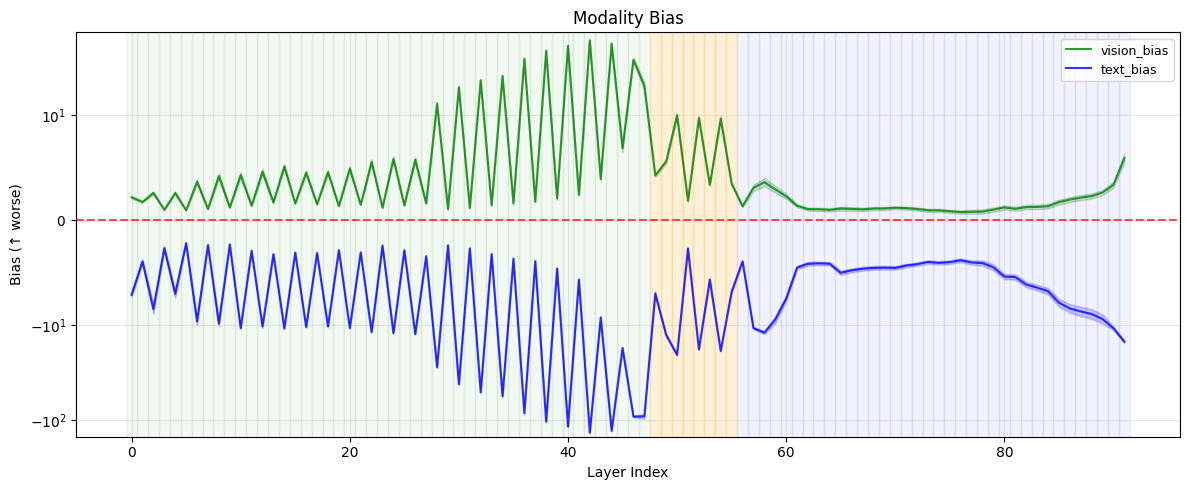

In [20]:
# Plot aggregated results with error bars
if agg_scores:
    bias_loader._classify_layers = lambda layers: BiasLayer._classify_layers(bias_loader, layers)
    bias_loader.plot = lambda scores, **kwargs: BiasLayer.plot(bias_loader, scores, **kwargs)
    bias_loader.plot(agg_scores)
else:
    print("No saved results found. Run jobs/bias_layer/run.sh first.")
